<a href="https://colab.research.google.com/github/clarkti5/introduction-to-statistics/blob/main/2_2_Considering_categorical_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Considering categorical data

---

#### Summary videos

- [Exploring categorical data](https://youtu.be/7NhNeADL8fA?si=GY_6ALa1keTTrS7_) (5 minutes)

#### Walkthrough videos

- [Contingency tables and bar plots](https://drive.google.com/file/d/1Eq_JSKwZtTLjVb4WP36F6CqqYZq2sAt9/view?usp=sharing) (10 minutes)
- [Bar plots with two variables and mosaic plots](https://drive.google.com/file/d/1uMm2jPFMdzd6y6MrcesODaWNdCBSoxM2/view?usp=sharing) (10 minutes)
- [Comparing numerical data across groups](https://drive.google.com/file/d/1sELAKlOq0IUg00Xa9JnX7ZGmaq2Kqfnc/view?usp=sharing) (7 minutes)

---

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from plotnine import *

Let's import the full data set from the Lending Club. This data set contains information on 10,000 loans.

In [ ]:
loans = pd.read_csv('https://raw.githubusercontent.com/clarkti5/math-209-data-sets/main/loans_full_schema.csv')
loans.head()

## Contingency tables and bar plots

The table below summarizes some data related to the `application_type` and `homeownership` variables.

In [ ]:
pd.crosstab(loans['application_type'], loans['homeownership'], margins = True, margins_name = 'Total')

This is called a **contigency table** (sometimes called a **two-way table**) and is a useful way of comparing categorical variables to each other. Below is a better formatted version of this table from page 61 of the textbook.

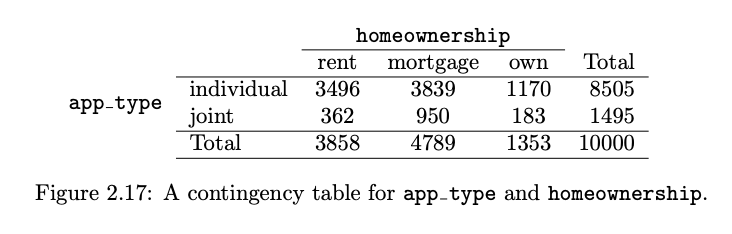

### Exercise

* How many people who owned their home had a joint application?
* How many renters had an individual application?
* How many individual applications are there, total?
* How many people had mortages, overall?

We can visualize categorical variables using **bar plots** as on page 62 of the textbook.

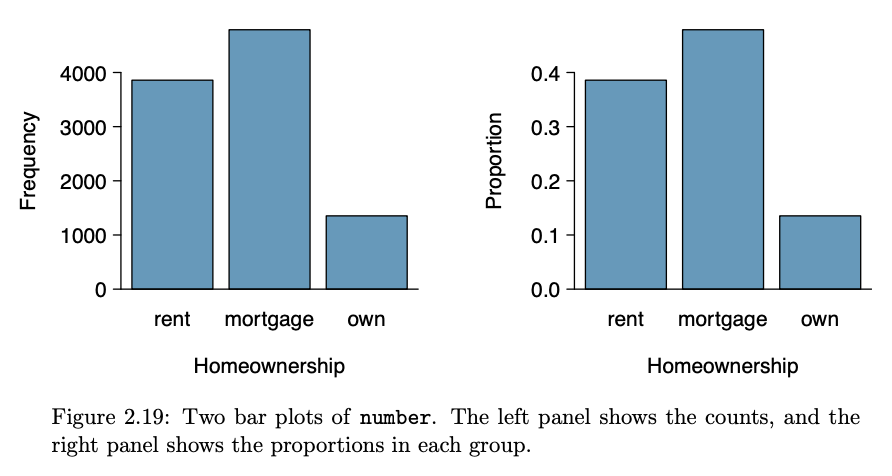

The code below can be used to reproduce these bar plots.

In [ ]:
(
  ggplot(loans) +
  aes(x = 'homeownership') +
  geom_bar()
)

In [ ]:
proportions = pd.DataFrame(loans['homeownership'].value_counts(normalize = True)).reset_index()

(
  ggplot(proportions) +
  aes(x = 'homeownership', y = 'proportion') +
  geom_col()
)

Notice how one of these plots is measuring the frequency of occurence for each level of `homeownership`, while the other is measuring the *proportion*, i.e. the frequency divided by the total.

### Questions

* What is the difference between a bar plot and a histogram?
* Why might we be interested in proportion instead of frequency?

## Using bar plots with two variables

**Stacked bar plots** and **side-by-side bar plots** are ways to visualize contigency table data or otherwise compare categorical variables, as on page 64 of the textbook.

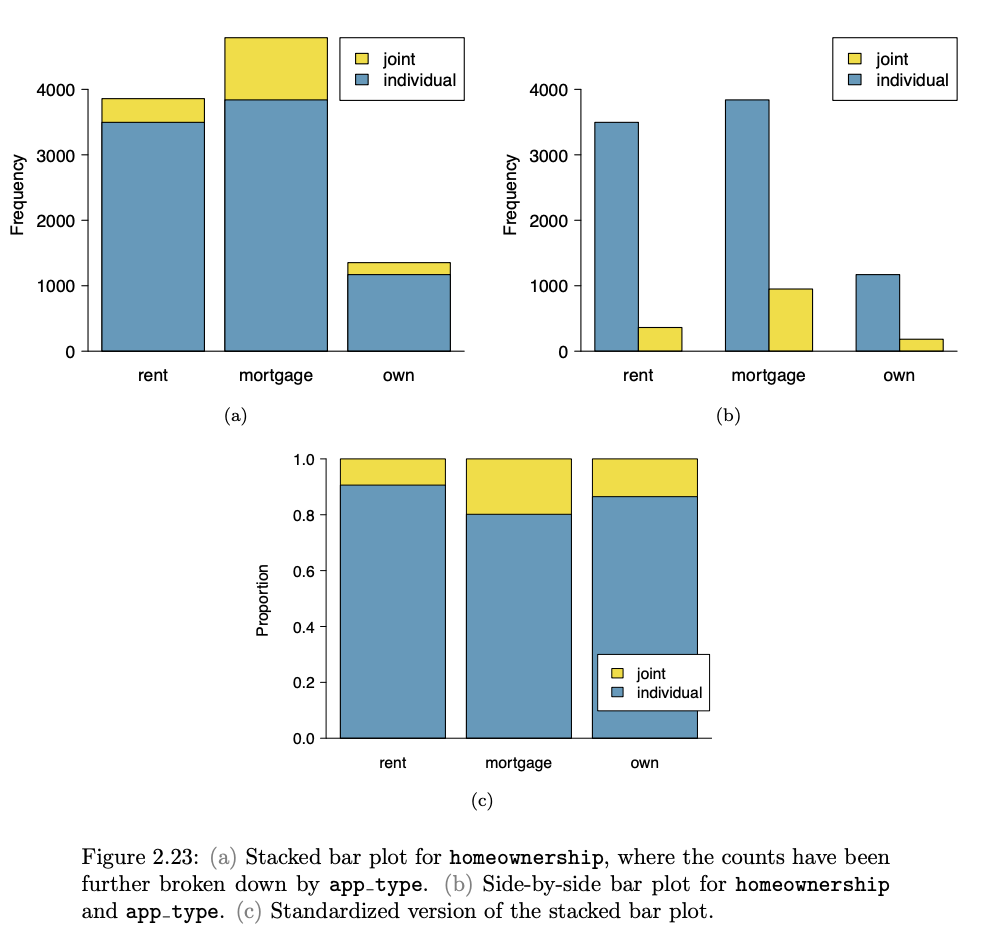

In [ ]:
(
  ggplot(loans) +
  aes(x = 'homeownership', fill = 'application_type') +
  geom_bar()
)

In [ ]:
(
  ggplot(loans) +
  aes(x = 'homeownership', fill = 'application_type',) +
  geom_bar(position = 'dodge')
)

In [ ]:
(
  ggplot(loans) +
  aes(x = 'homeownership', fill = 'application_type') +
  geom_bar(position = 'fill') +
  labs(y = 'proportion')
)

## Mosaic plots

A **mosaic plot** is another way to visualize contigency table data that also lets us compare relative group sizes.

In [ ]:
def mosaic(data, var1, var2):
  # Group by 'var1' and 'var2', then summarize counts
  df = data.groupby([var1, var2]).size().reset_index(name='count')

  # Calculate the total count for each value of 'var1'
  df['var1_count'] = [df[df[var1] == (df[var1][i])]['count'].sum() for i in range(len(df))]

  # Calculate the proportion of each count
  df['prop'] = df['count'] / df['var1_count']

  plot = (
  ggplot(df, aes(x = var1, y = 'prop', width = 'var1_count', fill = var2)) +
  geom_bar(stat = "identity", position = "fill", colour = "black") +
  facet_grid(cols = var1, scales = "free_x", space = "free_x") +
  theme(axis_text = element_blank(), axis_title = element_blank(), axis_ticks = element_blank())
  )

  return plot

In [ ]:
mosaic(loans, 'homeownership', 'application_type')

In [ ]:
mosaic(loans, 'application_type', 'homeownership')

## Comparing numerical data across groups

We can combine what we know about investigating numerical and categorical varaibles together to allow us to compare numerical variables across the different levels of a categorical variable.

In [ ]:
(
  ggplot(loans) +
  aes(x = 'homeownership', y = 'emp_length') +
  geom_boxplot() +
  labs(title = "Boxplot of employment length by homeownserhip")
)

### Question

What conclusion can you draw from this plot about `emp_length` in terms of `homeownership`?

We can also overlay histograms grouped by the levels of a categorical variable. Below is a combined histogram for `annual_income` across the levels of `application_type`.

In [ ]:
(
  ggplot(loans) +
  aes(x = 'annual_income', fill = 'application_type') +
  geom_histogram(bins = 100) +
  xlim(0, 500000) +
  labs(title = "Histogram of annual income by application type")
)

### Question

What conclusion(s) can you draw from the figure above?

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.